<a href="https://colab.research.google.com/github/peperjet/bc-ml/blob/main/real-estate-ml/apt2_260328.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
# 데이터 불러오기
import pandas as pd
import numpy as np

# 차트 및 폰트설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl
import seaborn as sns


# 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

mpl.rcParams['font.family'] = font_name
mpl.rcParams['axes.unicode_minus'] = False

# train 이라는 객체에 'train.csv' 파일 할당해 줍니다
train = pd.read_csv('/content/train.csv')



In [69]:
#폰트설치

!apt-get update -qq
!apt-get install -y fonts-nanum
!fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped dire

In [70]:
# train 데이터 상위 5개행 출력
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000


In [71]:
# train 데이터 전체 정보 요약
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1216553 entries, 0 to 1216552
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   transaction_id          1216553 non-null  int64  
 1   apartment_id            1216553 non-null  int64  
 2   city                    1216553 non-null  object 
 3   dong                    1216553 non-null  object 
 4   jibun                   1216553 non-null  object 
 5   apt                     1216553 non-null  object 
 6   addr_kr                 1216553 non-null  object 
 7   exclusive_use_area      1216553 non-null  float64
 8   year_of_completion      1216553 non-null  int64  
 9   transaction_year_month  1216553 non-null  int64  
 10  transaction_date        1216553 non-null  object 
 11  floor                   1216553 non-null  int64  
 12  transaction_real_price  1216553 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 120.7+ M

In [72]:
# 각 컬럼별 결측값 개수 출력
train.isnull().sum()

,0
transaction_id,0
apartment_id,0
city,0
dong,0
jibun,0
apt,0
addr_kr,0
exclusive_use_area,0
year_of_completion,0
transaction_year_month,0


In [73]:
# 수치형 컬럼의 통계를 요약하여 출력
train.describe()

,transaction_id,apartment_id,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price
count,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06
mean,6.091530e+05,6.299685e+03,7.816549e+01,1.998297e+03,2.012984e+05,9.343291e+00,3.822769e+04
std,3.526198e+05,3.581169e+03,2.915113e+01,8.941347e+00,2.905732e+02,6.606500e+00,3.104898e+04
min,0.000000e+00,0.000000e+00,9.260000e+00,1.961000e+03,2.008010e+05,-4.000000e+00,1.000000e+02
25%,3.041380e+05,3.345000e+03,5.976000e+01,1.993000e+03,2.010100e+05,4.000000e+00,1.900000e+04
50%,6.082760e+05,5.964000e+03,8.241000e+01,1.999000e+03,2.013120e+05,8.000000e+00,3.090000e+04
75%,9.124140e+05,9.436000e+03,8.497000e+01,2.005000e+03,2.015110e+05,1.300000e+01,4.700000e+04
max,1.234827e+06,1.265800e+04,4.243200e+02,2.017000e+03,2.017110e+05,8.000000e+01,8.200000e+05


In [74]:
# 범주형 컬럼 통계 요약 출력
train.describe(include=['object'])

,city,dong,jibun,apt,addr_kr,transaction_date
count,1216553,1216553,1216553,1216553,1216553,1216553
unique,2,473,8961,10440,12533,6
top,서울특별시,상계동,176-30,현대,용호동 944 오륙도에스케이뷰,11~20
freq,742285,29346,6594,13154,3220,408385


add_kr 주소


In [75]:
train['city'].value_counts()

,count
city,
서울특별시,742285
부산광역시,474268


In [76]:
train['city']=='부산광역시'

,city
0,False
1,False
2,False
3,False
4,False
...,...
1216548,True
1216549,True
1216550,True
1216551,True


In [77]:
train[train['city']=='부산광역시']

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [78]:
train.loc[train['city']=='부산광역시',:]

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [79]:
train.loc[train['city']=='부산광역시',['year_of_completion','transaction_year_month']]

,year_of_completion,transaction_year_month
650921,1998,200801
650922,2005,200801
650923,1997,200801
650924,1998,200801
650925,1997,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [80]:
train.iloc[:,[8,9]]

,year_of_completion,transaction_year_month
0,2002,200801
1,1973,200801
2,2007,200801
3,2003,200801
4,2004,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [81]:
train.iloc[9:20,[8,9]]

,year_of_completion,transaction_year_month
9,2006,200801
10,2004,200801
11,2002,200801
12,2003,200801
13,1999,200801
14,1999,200801
15,1999,200801
16,1999,200801
17,1968,200801
18,1999,200801


2단계 EDA

In [82]:
import pip
!pip install seaborn

In [83]:
plt.style.use("fivethirtyeight")

In [84]:
train = pd.read_csv('train.csv')


In [85]:
train.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000


In [86]:
#transaction_year_month 연도와 월을 분리해 줍니다
train['year'] = train['transaction_year_month'].astype(str).str[:4].astype(int)
train['month'] = train['transaction_year_month'].astype(str).str[4:].astype(int)

In [87]:
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500,2008,1
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000,2008,1
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500,2008,1
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000,2008,1
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000,2008,1


transaction_date

In [88]:
train['transaction_date'].value_counts()

,count
transaction_date,
11~20,408385
1~10,391715
21~31,250588
21~30,134017
21~28,22199
21~29,9649


In [89]:
# transaction_date에서 21~31, 21~30, 21~28, 21~29에 해당하는 값을 21~31로 변환

# 막대기 대신 리스트를 써서 깔끔하게 줄이는 방법
targets = ['21~30', '21~28', '21~29']
train.loc[train['transaction_date'].isin(targets), 'transaction_date'] = '21~31'


In [90]:
train['transaction_date'].value_counts()

,count
transaction_date,
21~31,416453
11~20,408385
1~10,391715


plt.figure  가로크기 세로크기
plt.그래프 종류() or sns.그래프 종류()
사용하고 싶은 그래프 종류에 따라 맞춰서 종류를 사용해야하고, 패키지에 있는 그래프 종류를 사용하면됩니다


In [91]:
# pie chart

seoul_busan = train['city'].value_counts()
seoul_busan

,count
city,
서울특별시,742285
부산광역시,474268


In [92]:

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
[x for x in fonts if 'Nanum' in x]

['NanumGothic']

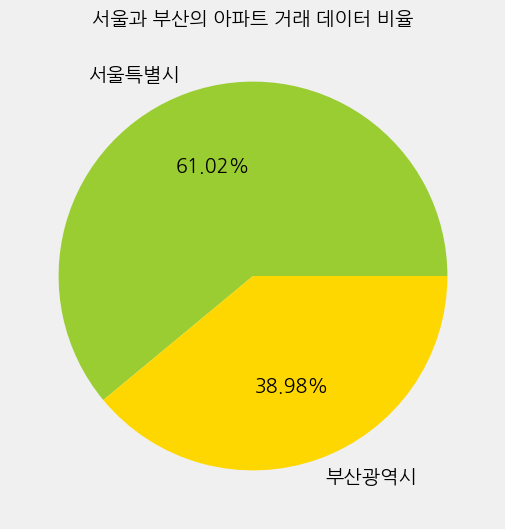

In [126]:
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

color = ['yellowgreen', 'gold']
iangs = ['서울특별시', '부산광역시']

plt.figure(figsize=(8,6))
plt.pie(
    seoul_busan,
    labels=iangs,
    colors=color,
    autopct='%.2f%%',
    textprops={'fontproperties': fontprop}
)
plt.title('서울과 부산의 아파트 거래 데이터 비율', fontsize=20, fontproperties=fontprop)
plt.show()

countplot

In [94]:
#연도별 count table
train['year'] = train['transaction_year_month'].astype(str).str[:4].astype(int)
train['month'] = train['transaction_year_month'].astype(str).str[4:].astype(int)
train_year_count = train['year'].value_counts().sort_index(ascending=True)
train_year_count

,count
year,
2008,100066
2009,127869
2010,102823
2011,98586
2012,70065
2013,109738
2014,136649
2015,181195
2016,165664


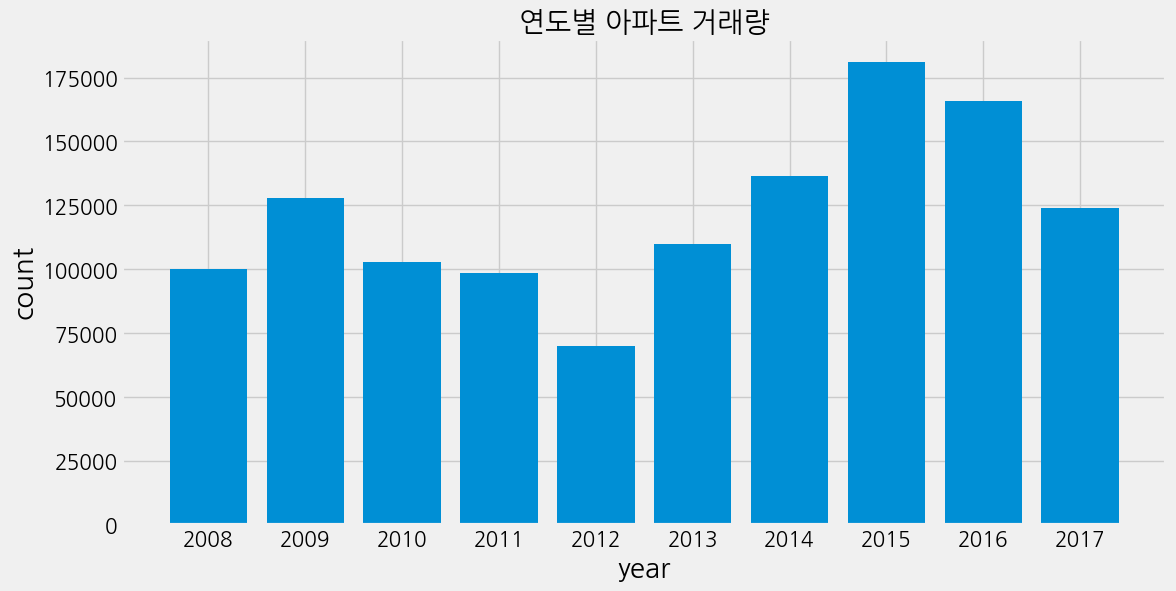

In [95]:
# matplotlib을 이용해 연도별 아파트 거래량 표기

plt.figure(figsize=(12,6))
plt.bar(train_year_count.index.astype(str), train_year_count.values)

plt.title('연도별 아파트 거래량', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('year', size=20)
plt.ylabel('count', size=20)

plt.show()

/tmp/ipykernel_45207/3336409558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=train,  palette='Set2')


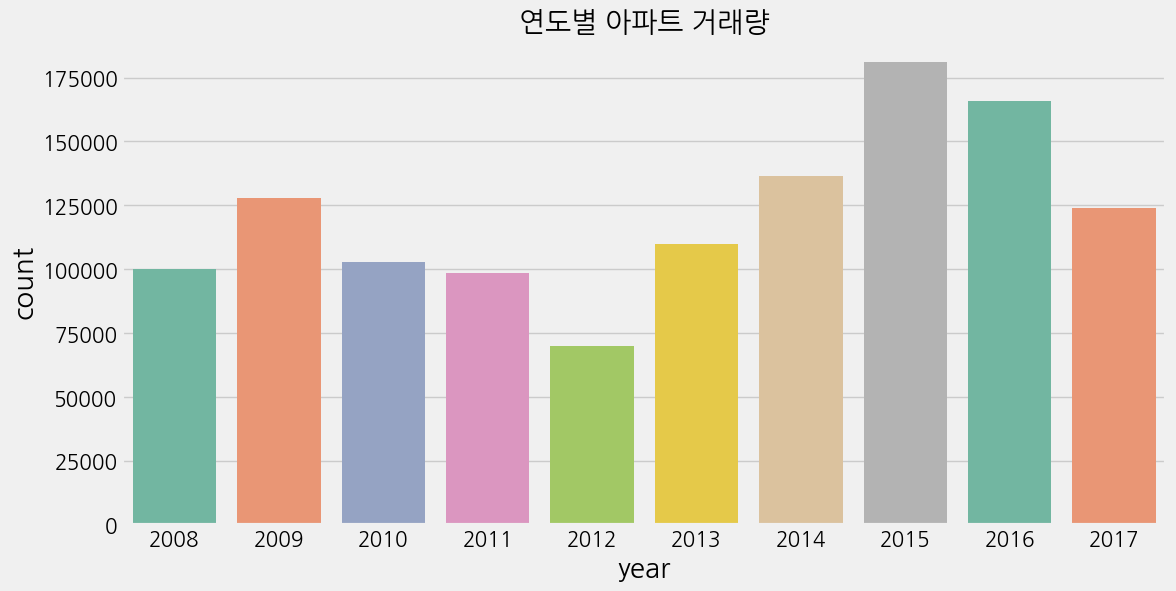

In [96]:
# seaborn의 countplot을 아용해 아파트 연도별 거래량

plt.figure(figsize=(12,6))
sns.countplot(x='year', data=train,  palette='Set2')
plt.title('연도별 아파트 거래량', size=20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('year', size=20)
plt.ylabel('count', size=20)

plt.show()

palette='Set2'      # 부드럽고 예쁨 (추천)
palette='Set3'      # 더 컬러풀
palette='tab10'     # 선명한 색
palette='pastel'    # 연한 색
palette='coolwarm'  # 그라데이션 느낌


seaborn은 기본이 단색이라 palette 넣어야 화려해진다

In [97]:
# 월별 count table

train_month_count = train['month'].value_counts().sort_index(ascending=True)
train_month_count

,count
month,
1,85622
2,95199
3,125958
4,115363
5,110536
6,109841
7,102973
8,96163
9,104061


In [98]:
# 월별 count table

train_month_count = train['transaction_date'].value_counts().sort_index(ascending=True).to_frame()
train_month_count

,count
transaction_date,
11~20,408385
1~10,391715
21~31,416453


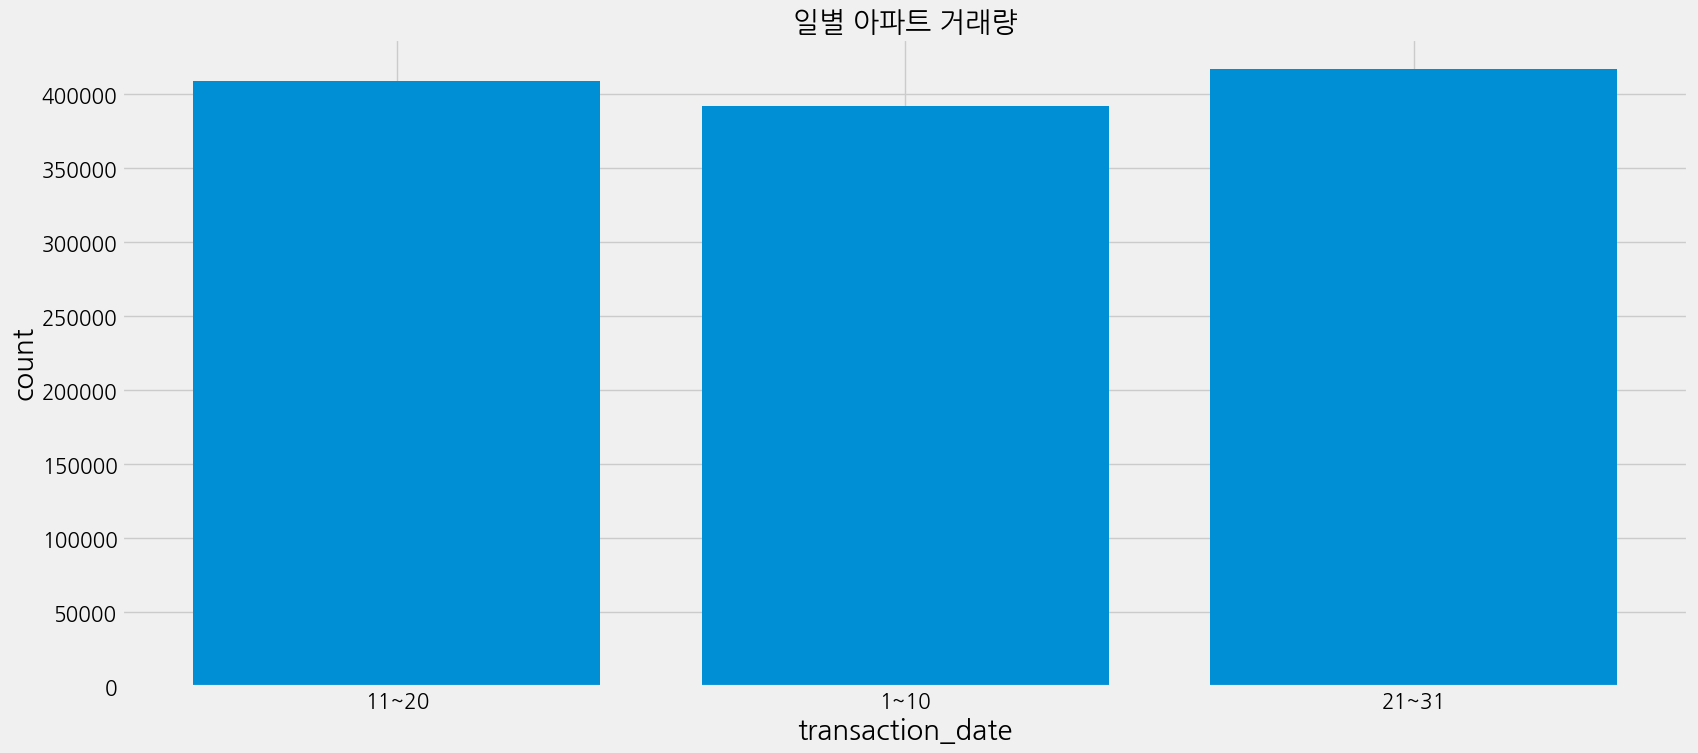

In [99]:
# matplotlib 이용해 일별 아파트 거래량

plt.figure(figsize=(18,8))
plt.bar(train_month_count.index.astype(str), train_month_count['count'])
plt.title('일별 아파트 거래량', size = 20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('transaction_date', size=20)
plt.ylabel('count', size=20)

plt.show()

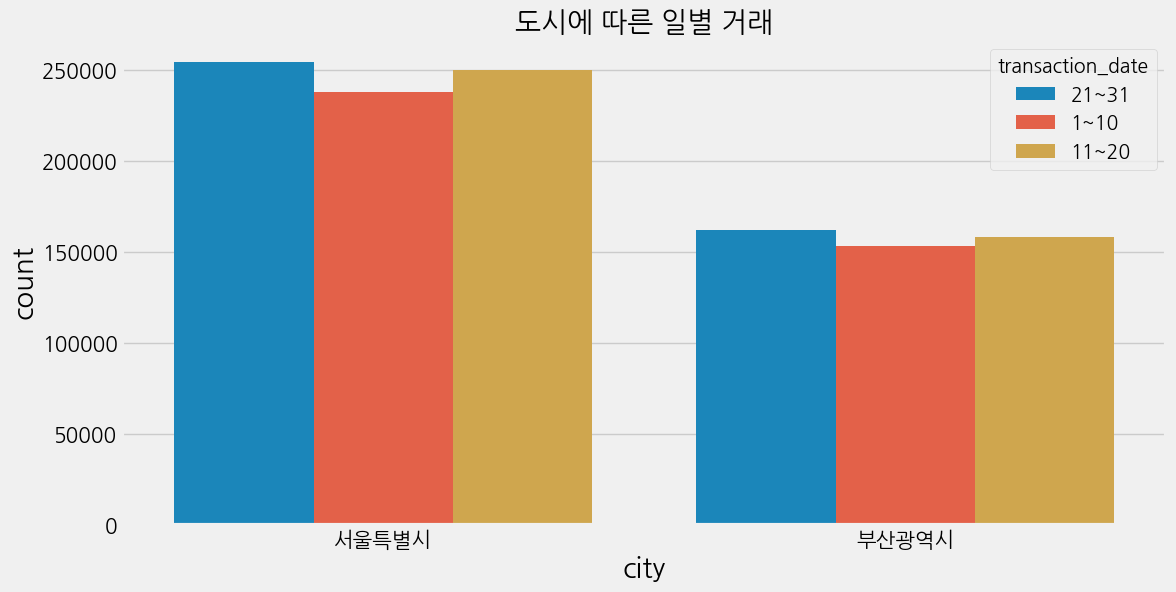

In [100]:
# 이변량 countplot

# seaborn의 countplot 도시에 따른 일별 거래

plt.figure(figsize=(12,6))
sns.countplot( x ='city', hue = 'transaction_date', data=train)
plt.title('도시에 따른 일별 거래', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('city', size=20)
plt.ylabel('count', size=20)

plt.show()

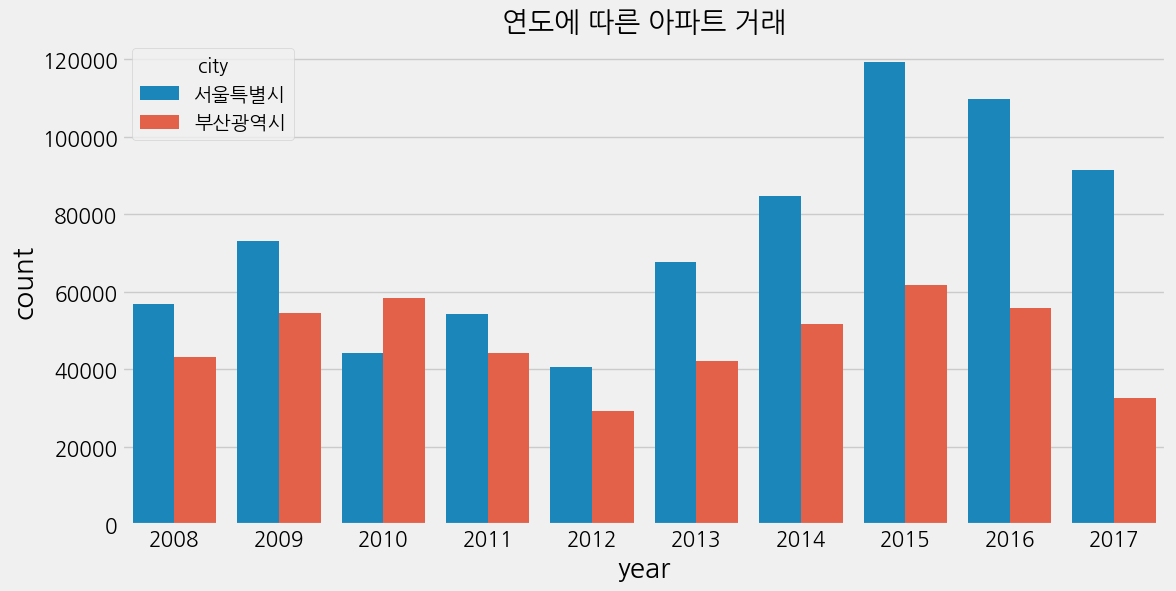

In [64]:
# seaborn의 countplot 연도에 따른 아파트 거래

plt.figure(figsize=(12,6))
sns.countplot(x = 'year', hue='city', data=train)
plt.title('연도에 따른 아파트 거래', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('year', size=20)
plt.ylabel('count', size=20)

plt.show()

In [65]:
# 서울특별시 데이터 모아서 출력
seoul_data =train.loc[train['city']=='서울특별시',:]
seoul_data.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500,2008,1
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000,2008,1


In [66]:
# 서울특별시 지역별로 아파트 평균 거래가 pivot table을 만들어보기
price_seoul_dong = seoul_data.groupby(['dong'])[['transaction_real_price']].mean()
price_seul_dong_top_10 = price_seoul_dong.sort_values(['transaction_real_price'],ascending = False)[:10]

price_seul_dong_top_10

,transaction_real_price
dong,
장충동1가,269888.888889
압구정동,164534.722914
청암동,161403.700000
용산동5가,153497.331633
회현동2가,139906.140351
반포동,132489.395651
한남동,122593.293264
서빙고동,116547.239777
대치동,116320.538909


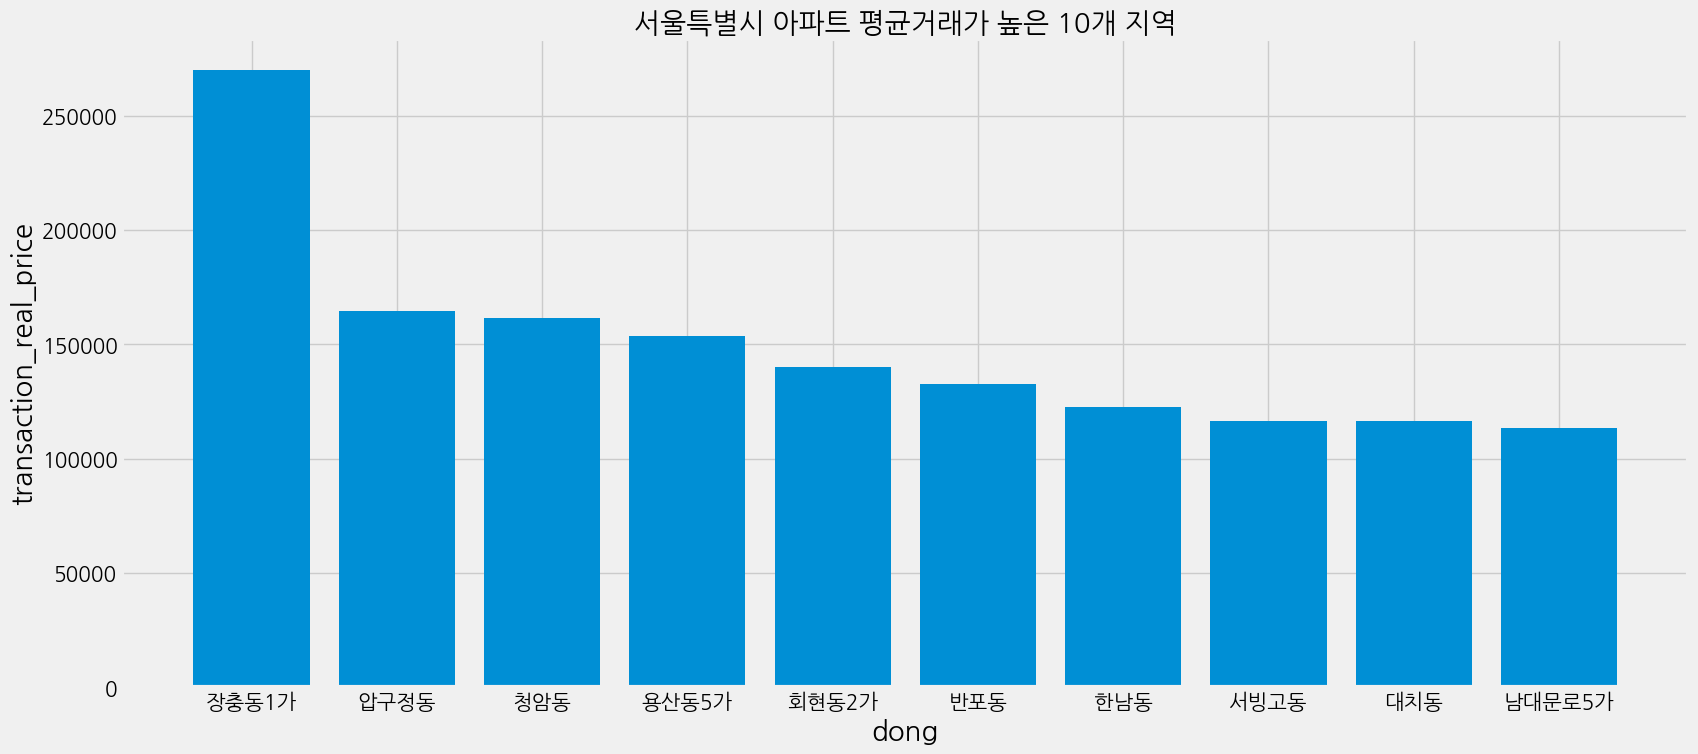

In [67]:
# 세로 barplot

# matplotlib의 bar를 이용해 서울특별히 아파트 평균거래가 높은 10개 지역
plt.figure(figsize = (18,8))
plt.bar(price_seul_dong_top_10.index, price_seul_dong_top_10['transaction_real_price'])
plt.title('서울특별시 아파트 평균거래가 높은 10개 지역', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('dong', size=20)
plt.ylabel('transaction_real_price', size=20)

plt.show()

### 부산광역시 아파트 평균 거래가 분석

In [101]:
# 부산광역시 데이터 모아서 출력
busan_data = train.loc[train['city']=='부산광역시',:]
busan_data.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.09,1998,200801,1~10,4,7900,2008,1
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.97,2005,200801,1~10,12,13000,2008,1


In [102]:
# 부산광역시 지역별로 아파트 평균 거래가 pivot table을 만들어보기
price_busan_dong = busan_data.groupby(['dong'])[['transaction_real_price']].mean()
price_busan_dong_top_10 = price_busan_dong.sort_values(['transaction_real_price'],ascending = False)[:10]

price_busan_dong_top_10

,transaction_real_price
dong,
대교동1가,49786.086957
우동,45634.265235
명륜동,38070.565761
충무동1가,35907.074627
남천동,34514.667134
명지동,33570.809676
민락동,33237.740305
중동,31790.139473
장전동,29908.275735


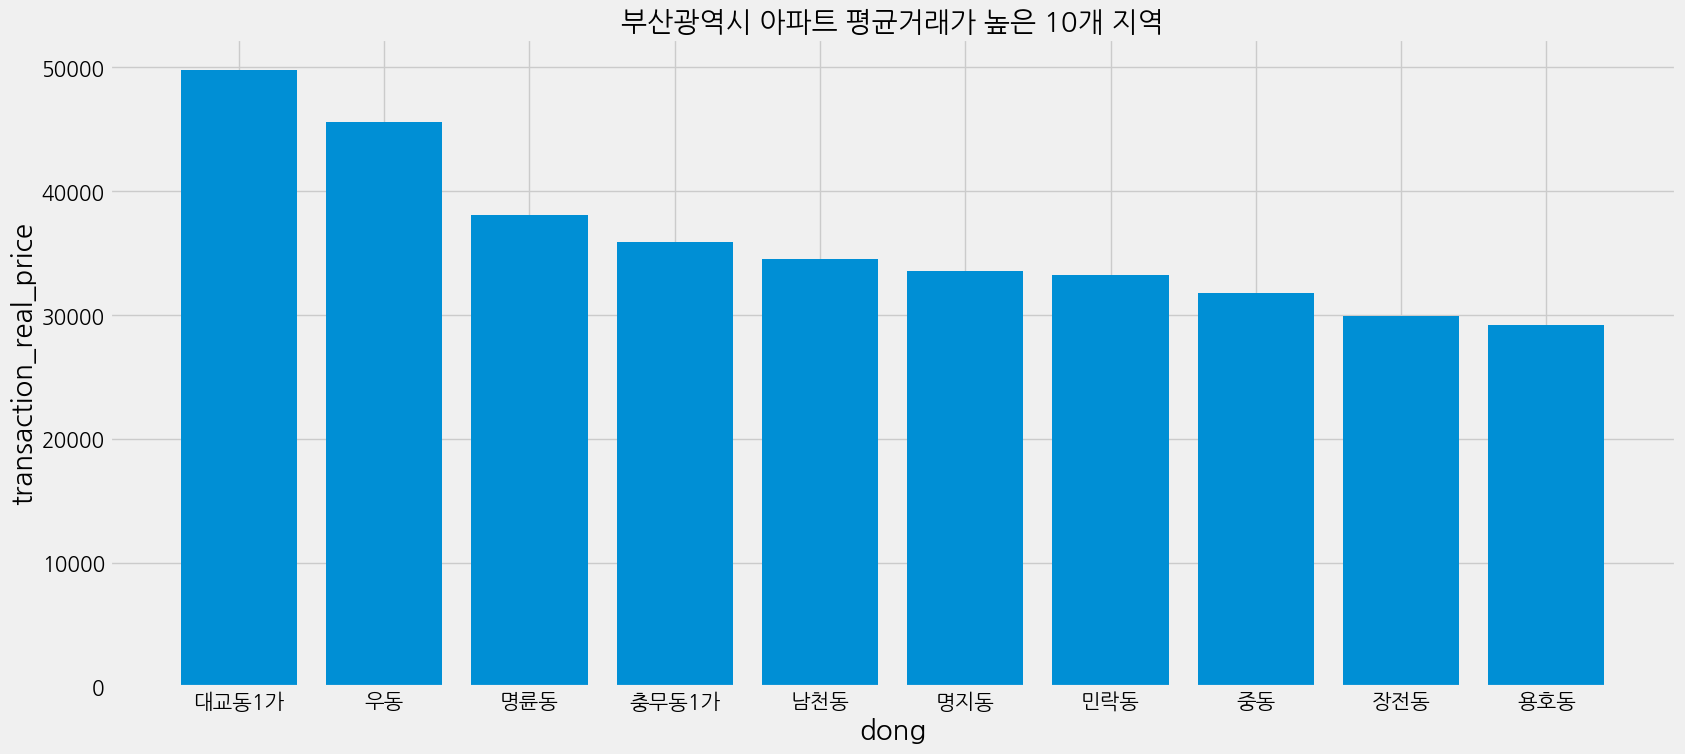

In [103]:
# 세로 barplot

# matplotlib의 bar를 이용해 부산광역시 아파트 평균거래가 높은 10개 지역
plt.figure(figsize = (18,8))
plt.bar(price_busan_dong_top_10.index, price_busan_dong_top_10['transaction_real_price'])
plt.title('부산광역시 아파트 평균거래가 높은 10개 지역', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('dong', size=20)
plt.ylabel('transaction_real_price', size=20)

plt.show()

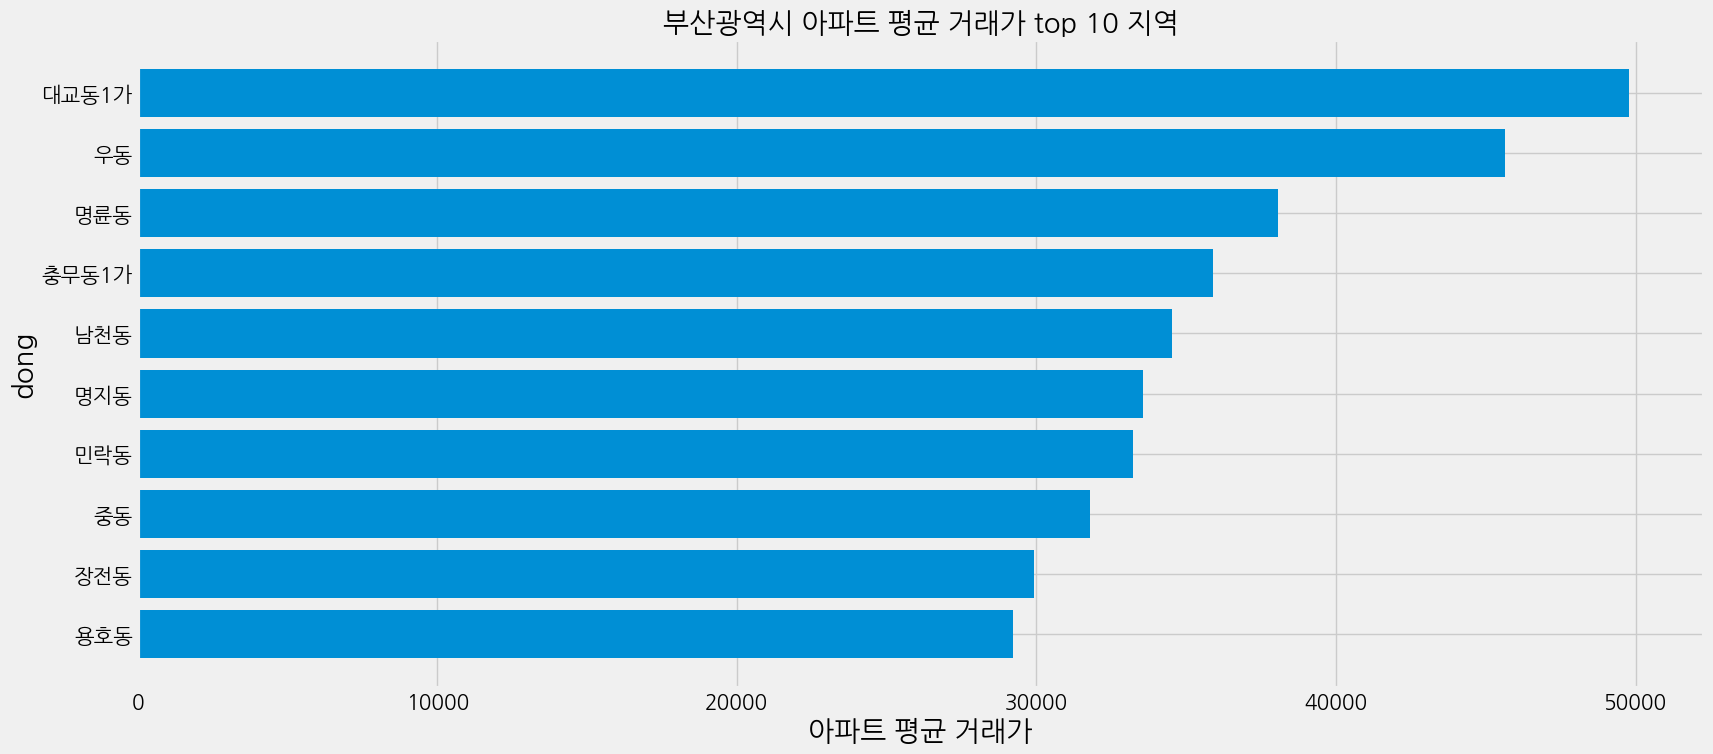

In [104]:
# 가로 barplot

# matplotlib의 bar를 이용해 부산광역시 아파트 평균거래가 높은 10개 지역을 '가로'로 나타내기

plt.figure(figsize = (18,8))
plt.barh(price_busan_dong_top_10['transaction_real_price'].sort_values().index, price_busan_dong_top_10['transaction_real_price'].sort_values())
plt.title('부산광역시 아파트 평균 거래가 top 10 지역', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('아파트 평균 거래가', size = 20)
plt.ylabel('dong', size = 20)

plt.show()

/tmp/ipykernel_45207/3302783175.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='transaction_real_price', y = price_busan_dong_top_10.index, orient='h', data = price_busan_dong_top_10, palette='Set2')


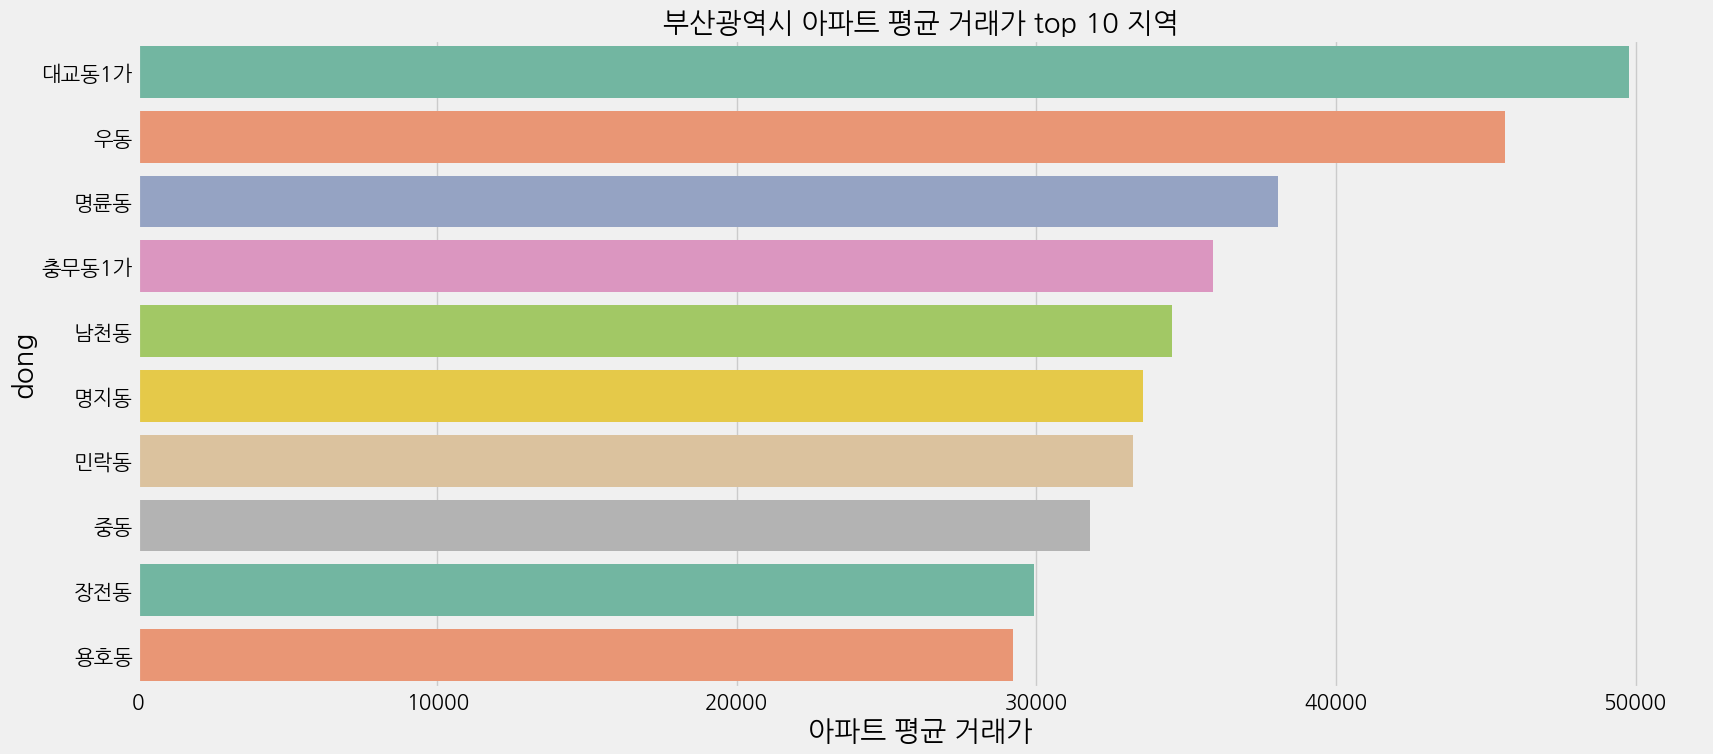

In [105]:
# seaborn의 barplot을 이용해 부산광역시 아파트 평균거래가 높은 10개 지역을 '가로'로 나타내기

plt.figure(figsize = (18,8))
sns.barplot(x='transaction_real_price', y = price_busan_dong_top_10.index, orient='h', data = price_busan_dong_top_10, palette='Set2')
plt.title('부산광역시 아파트 평균 거래가 top 10 지역', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('아파트 평균 거래가', size = 20)
plt.ylabel('dong', size = 20)

plt.show()

In [106]:
train.loc[train['dong']=='장충동1가','apt'].unique()

array(['장충동라임카운티', '상지리츠빌장충동카일룸', '장충레지던스'], dtype=object)

In [107]:
train.loc[train['dong']=='대교동1가','apt'].unique()

array(['원광브릿지타워'], dtype=object)

plt.axhline() : 그래프에 가로줄
plt.axvline() : 그래프에 세로줄
plt.annotate() : 그래프에 화살표, 주석 달 때
plt.text() : 그래프에 말문구 삽입할 때

/tmp/ipykernel_45207/4056567760.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = price_seoul_dong_top_10.index, y = 'transaction_real_price', data = price_seoul_dong_top_10,  palette='Set3')


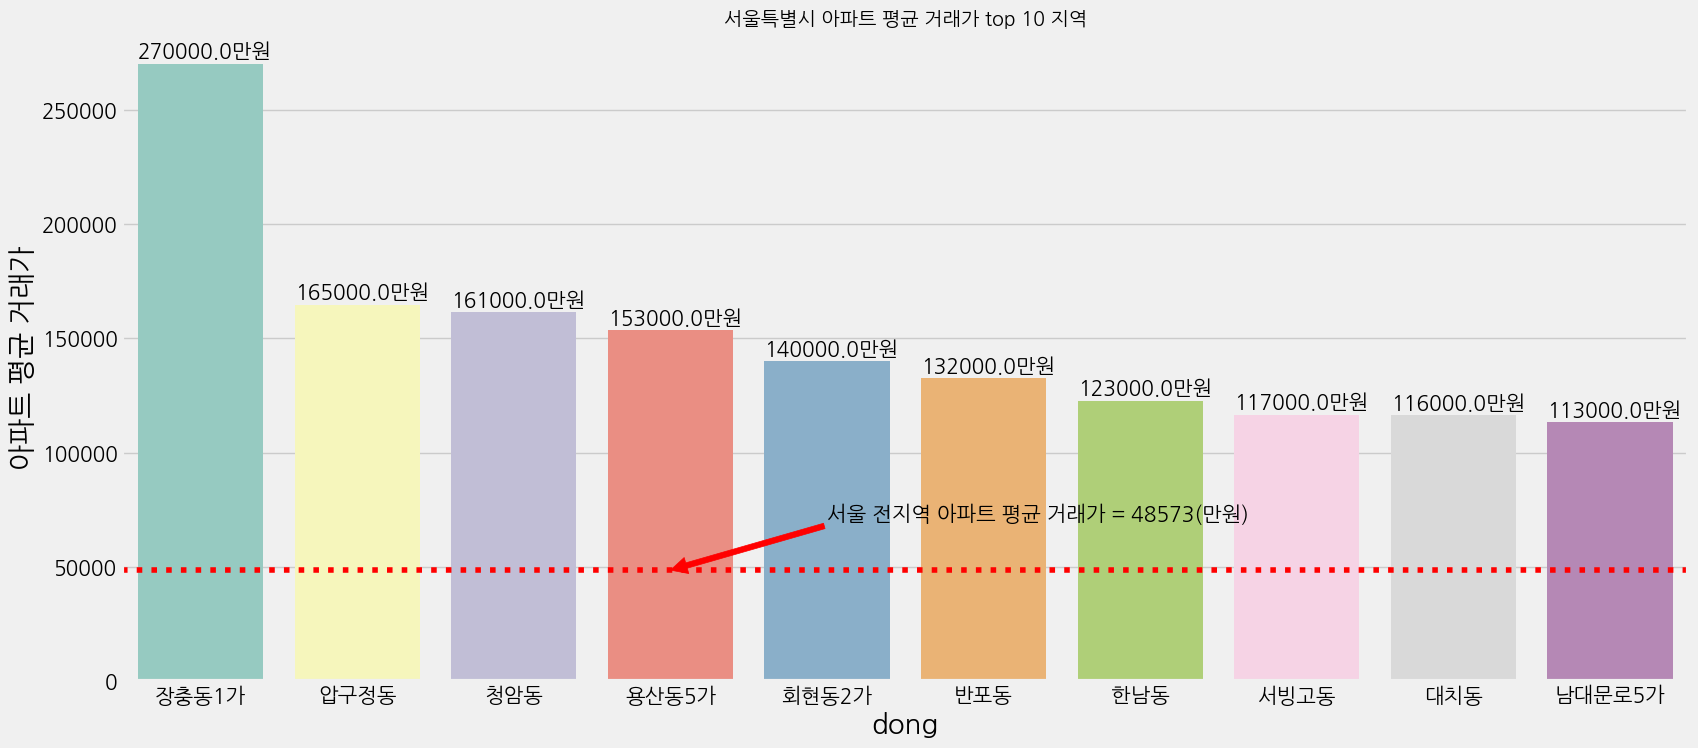

In [108]:
# Re-define fontprop for text properties
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fontprop = fm.FontProperties(fname=font_path)

# 서울특별시 데이터 모아서 출력
seoul_data = train.loc[train['city']=='서울특별시',:]

# 서울특별시 지역별로 아파트 평균 거래가 pivot table을 만들어보기
price_seoul_dong = seoul_data.groupby(['dong'])[['transaction_real_price']].mean()
price_seoul_dong_top_10 = price_seoul_dong.sort_values(['transaction_real_price'],ascending = False)[:10]

plt.figure(figsize = (18,8))
sns.barplot(x = price_seoul_dong_top_10.index, y = 'transaction_real_price', data = price_seoul_dong_top_10,  palette='Set3')
plt.title('서울특별시 아파트 평균 거래가 top 10 지역', size=20, fontproperties=fontprop)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('dong', size = 20, fontproperties=fontprop)
plt.ylabel('아파트 평균 거래가', size=20, fontproperties=fontprop)

plt.axhline(48573, color='red', linestyle=':')
plt.annotate(
    '서울 전지역 아파트 평균 거래가 = 48573(만원)',
    xy = (3,48573),
    xytext=(4,70000),
    arrowprops={'color':'red'},
    size=15,
    fontproperties=fontprop
)

for i in range(len(price_seoul_dong_top_10)):
    plt.text(
        x = i - 0.4,
        y = price_seoul_dong_top_10['transaction_real_price'].iloc[i] + 2500,
        s = str(round(price_seoul_dong_top_10['transaction_real_price'].iloc[i], -3)) + '만원',
        size=15,
        fontproperties=fontprop
    )
plt.show()

일변량 히스토그램

matplotlib 활용 : plt.hist(사용할 데이터, bins=ㅁ)
seaborn 활용:sns.barplot(x=x축에 사용할 컬럼, data=사용할데이터, bins=ㅁ)


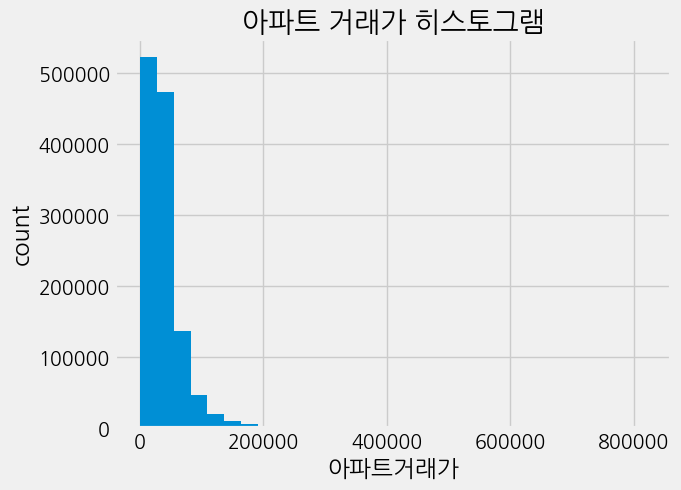

In [109]:
# matplotlib 히스토그램

plt.hist(train['transaction_real_price'], bins = 30)
plt.title('아파트 거래가 히스토그램', size = 20)

plt.xlabel('아파트거래가')
plt.ylabel('count')
plt.show()

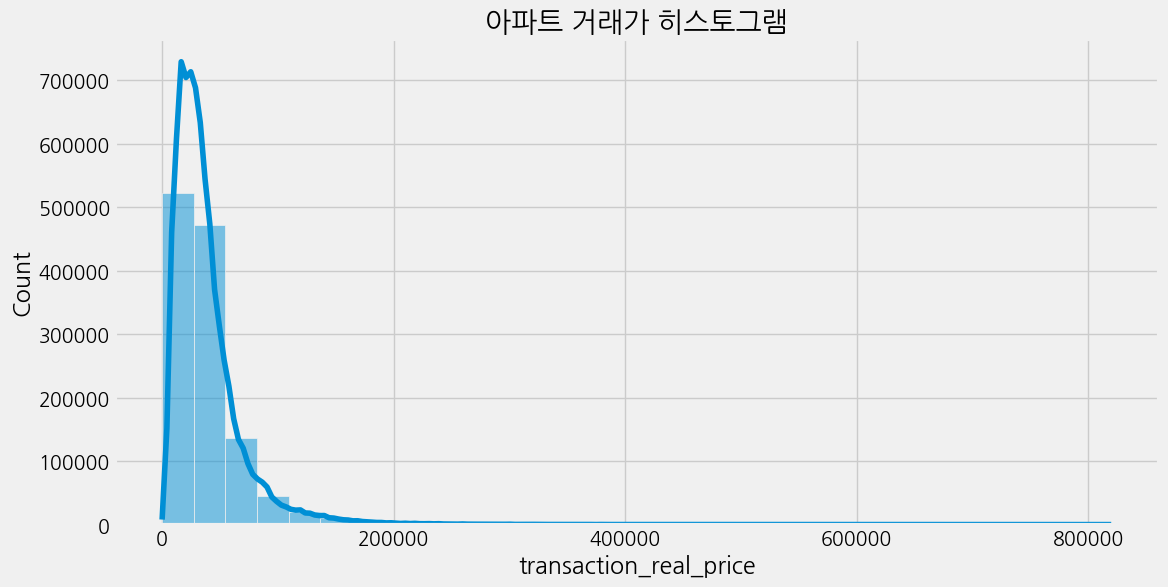

In [110]:
# seaborn 히스토그램

plt.figure(figsize=(12,6))
sns.histplot(train['transaction_real_price'], bins=30, kde=True)
plt.title('아파트 거래가 히스토그램', size=20)

plt.show()

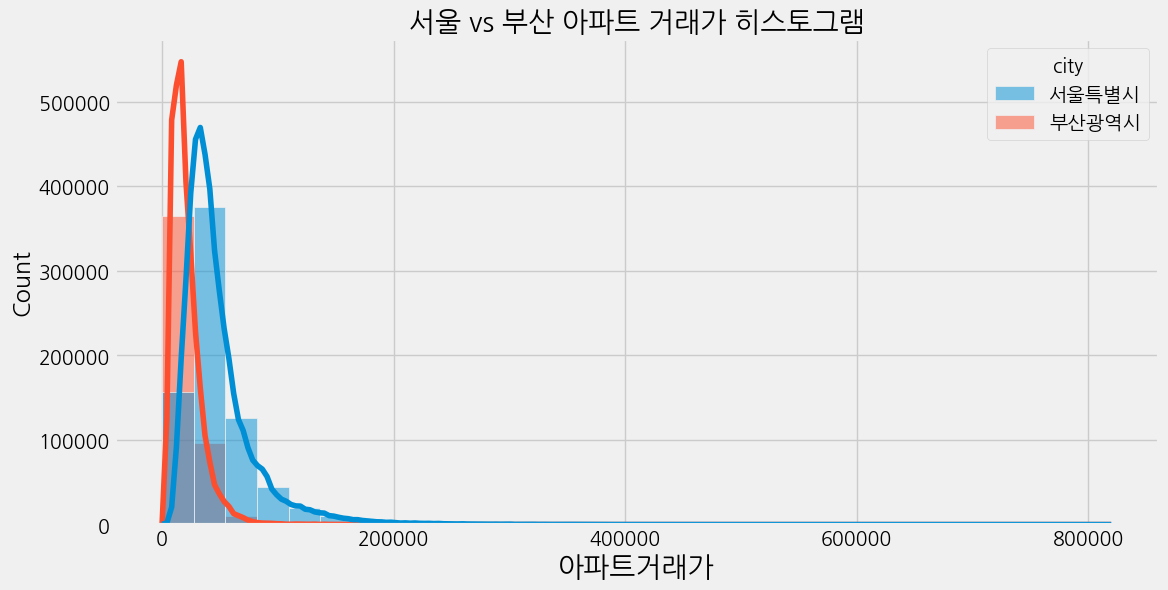

In [111]:
# matplotlib 히스토그램  서울 vs 부산

plt.figure(figsize=(12,6))
sns.histplot(x='transaction_real_price', data=train, kde=True, hue='city', bins=30)

plt.title('서울 vs 부산 아파트 거래가 히스토그램', size=20)
plt.xlabel('아파트거래가', size=20)
plt.show()

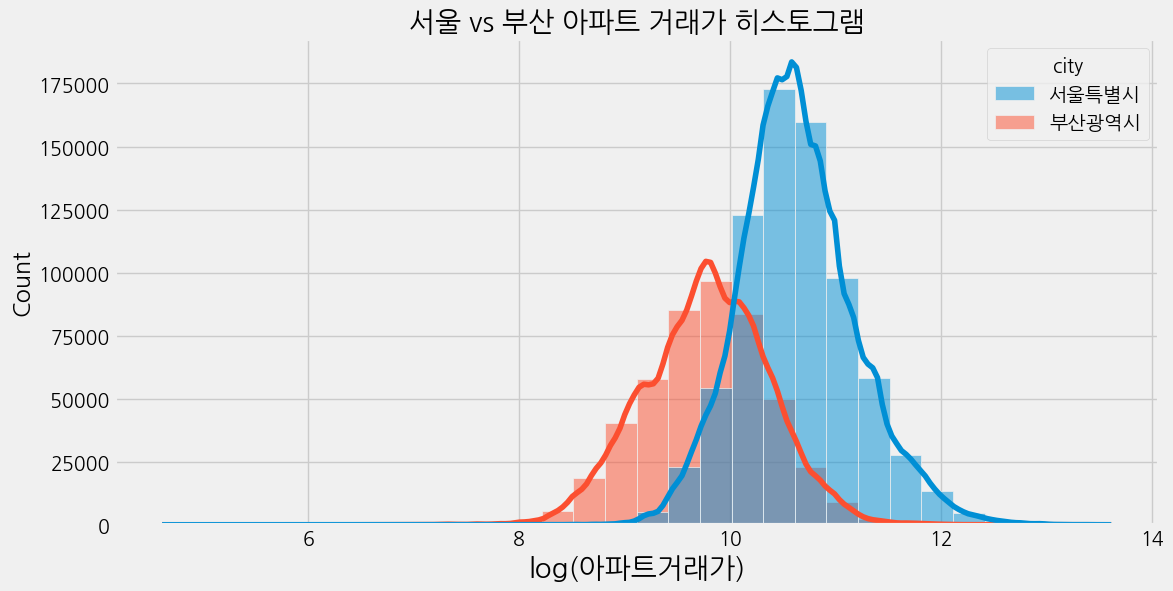

In [112]:
# 보다 명확한 차이를 확인하기 위한 로그 취해서 비교

plt.figure(figsize=(12,6))
sns.histplot(x = np.log1p(train['transaction_real_price']), data=train, kde=True, hue='city', bins=30)
plt.title('서울 vs 부산 아파트 거래가 히스토그램', size=20)

plt.xlabel('log(아파트거래가)', size=20)
plt.show()


일변량 boxplot

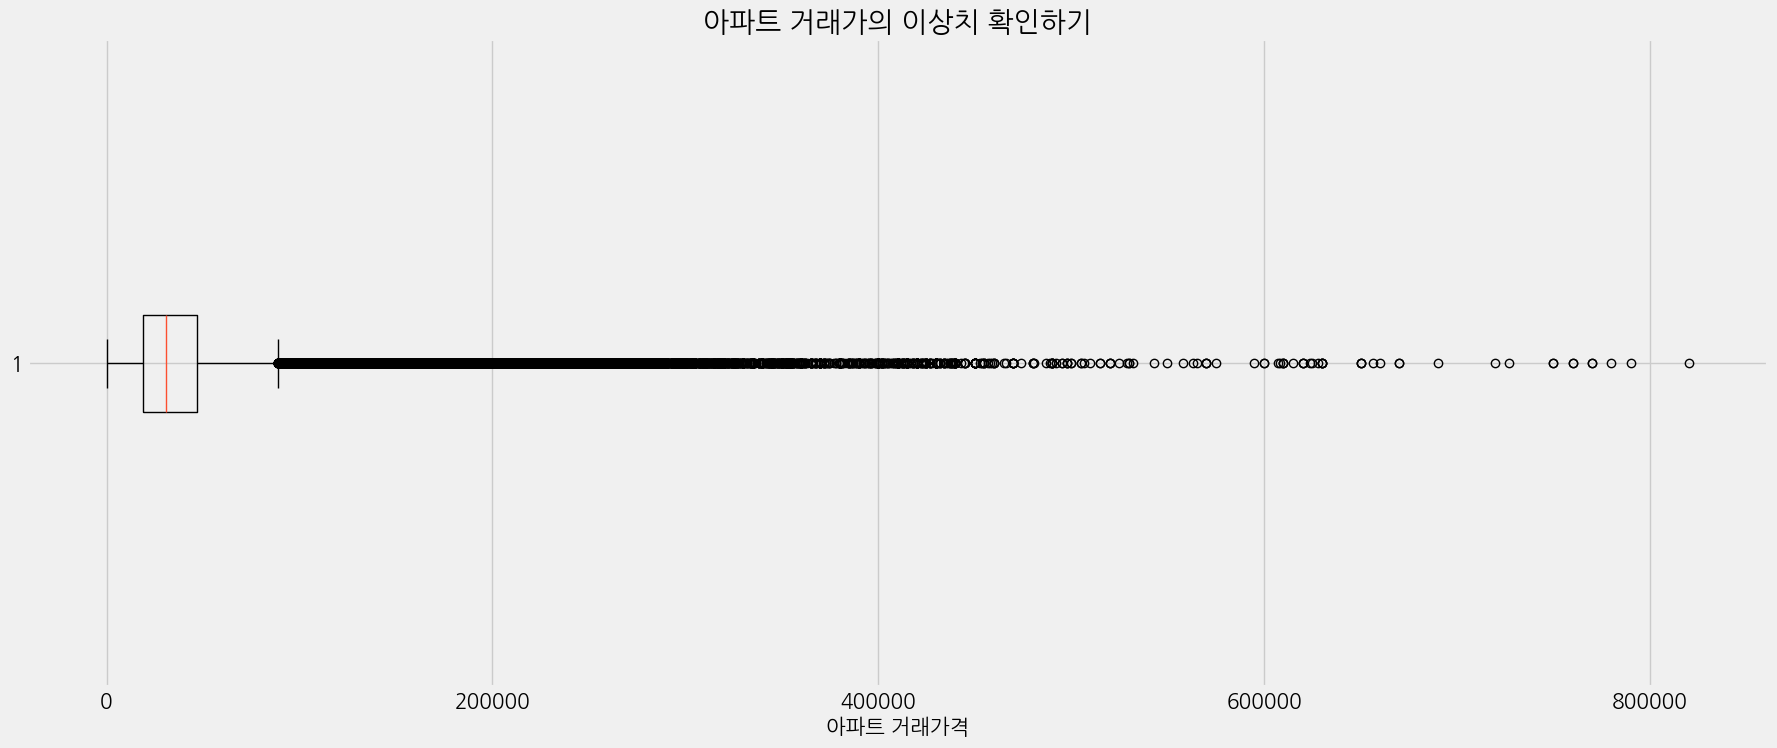

In [113]:
# plt의 boxplot을 통해 아파트 거래가의 이상치 확인하기

plt.figure(figsize = (20,8))
plt.boxplot(train['transaction_real_price'], vert=False)
plt.title('아파트 거래가의 이상치 확인하기', size = 20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('아파트 거래가격', size=15)

plt.show()

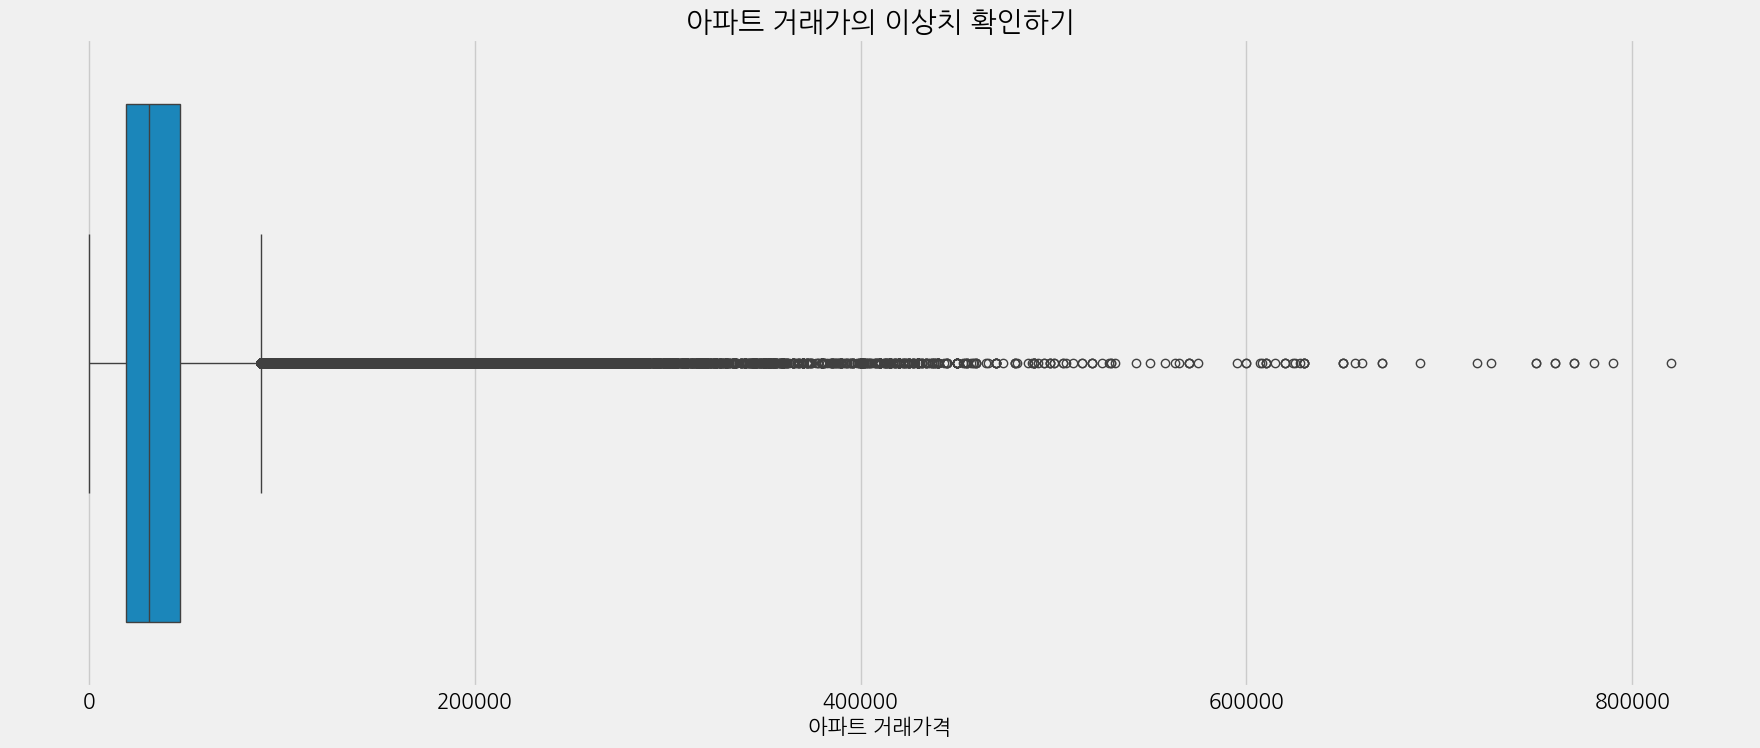

In [114]:
# seaborn의 boxplot을 통해 아파트 거래가의 이상치 확인

plt.figure(figsize = (20,8))
sns.boxplot(x = 'transaction_real_price', data=train)
plt.title('아파트 거래가의 이상치 확인하기', size = 20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('아파트 거래가격', size =15)
plt.show()

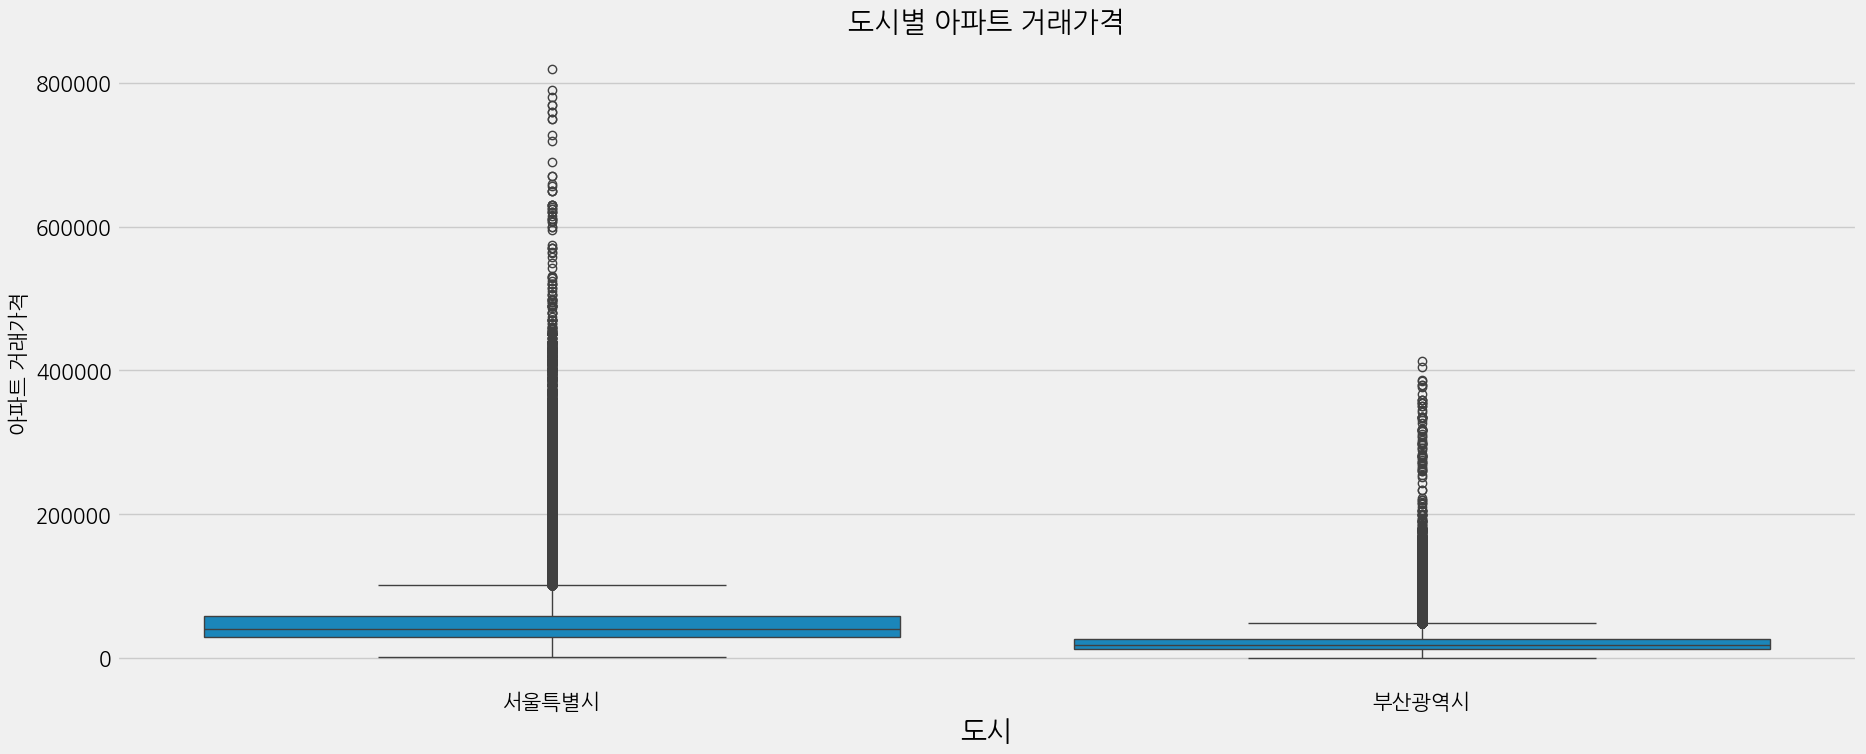

In [115]:
# seaborn의 boxplot : 도시별 아파트 거래가격

plt.figure(figsize = (20,8))
sns.boxplot(x = 'city', y = 'transaction_real_price', data=train)
plt.title('도시별 아파트 거래가격', size = 20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('도시', size = 20)
plt.ylabel('아파트 거래가격', size=15)

plt.show()

+1 : 완벽한 양의 선형 상관관계
-1 : 완벽한 음의 선형 상관관계


In [116]:
# 상관계수 값을 cor라는 객체에 할당하기

# 숫자형 컬럼만 선택하여 상관계수 계산
cor = train.select_dtypes(include=['number']).corr()
cor

,transaction_id,apartment_id,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price,year,month
transaction_id,1.000000,-0.050520,0.039815,0.011021,0.205657,0.061906,-0.120734,0.205642,0.007550
apartment_id,-0.050520,1.000000,0.015098,-0.042868,-0.002918,-0.011769,0.017576,-0.002870,-0.004386
exclusive_use_area,0.039815,0.015098,1.000000,0.168540,0.019041,0.134716,0.561563,0.018788,0.022899
year_of_completion,0.011021,-0.042868,0.168540,1.000000,0.092881,0.243510,0.052656,0.092627,0.025165
transaction_year_month,0.205657,-0.002918,0.019041,0.092881,1.000000,0.013425,0.183910,0.999936,0.036130
floor,0.061906,-0.011769,0.134716,0.243510,0.013425,1.000000,0.112278,0.013288,0.012513
transaction_real_price,-0.120734,0.017576,0.561563,0.052656,0.183910,0.112278,1.000000,0.183714,0.022886
year,0.205642,-0.002870,0.018788,0.092627,0.999936,0.013288,0.183714,1.000000,0.024791
month,0.007550,-0.004386,0.022899,0.025165,0.036130,0.012513,0.022886,0.024791,1.000000


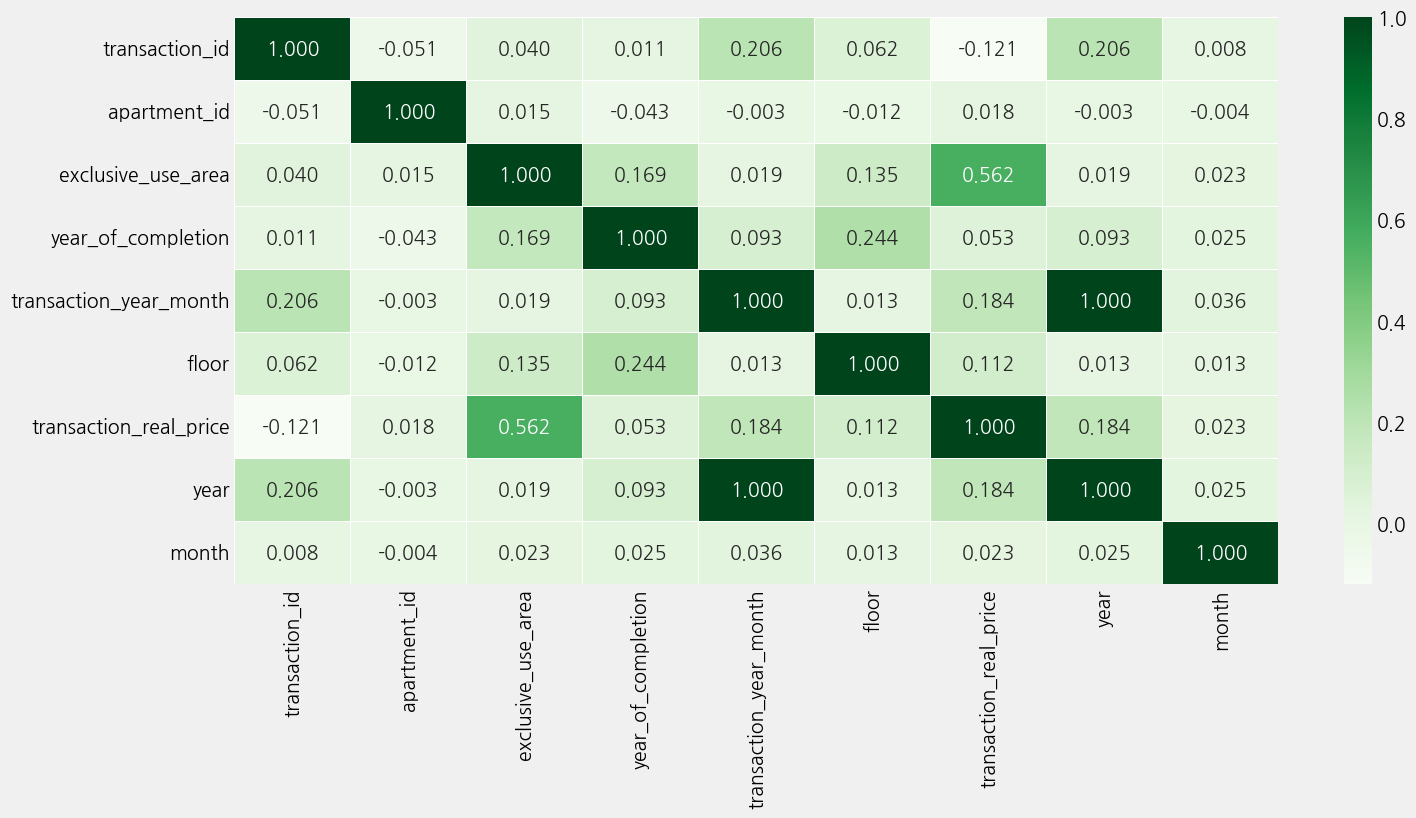

In [117]:
# 상관관계 테이블을 보기 쉬운 형태로 만들기

plt.figure(figsize=(15,7))
sns.heatmap(cor,cmap="Greens", annot=True, linewidths=0.5, fmt=".3f", cbar = True)
plt.show()

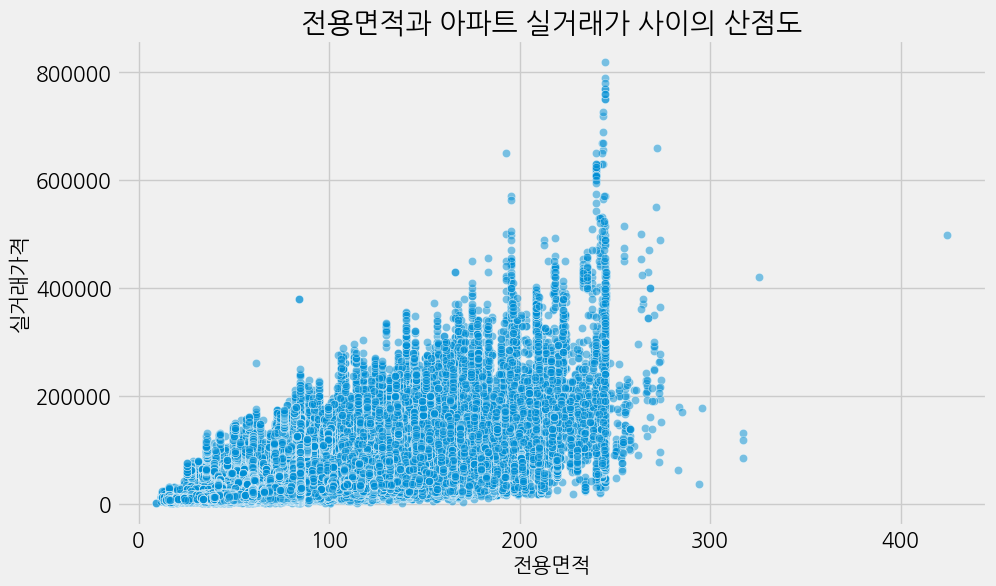

In [118]:
# 전용면적과 아파트 실거래가의 산점도

plt.figure(figsize=(10, 6))
sns.scatterplot(x='exclusive_use_area', y='transaction_real_price', data=train, alpha=0.5)
plt.title('전용면적과 아파트 실거래가 사이의 산점도', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('전용면적', size=15)
plt.ylabel('실거래가격', size=15)

plt.show()

<Figure size 1200x800 with 0 Axes>

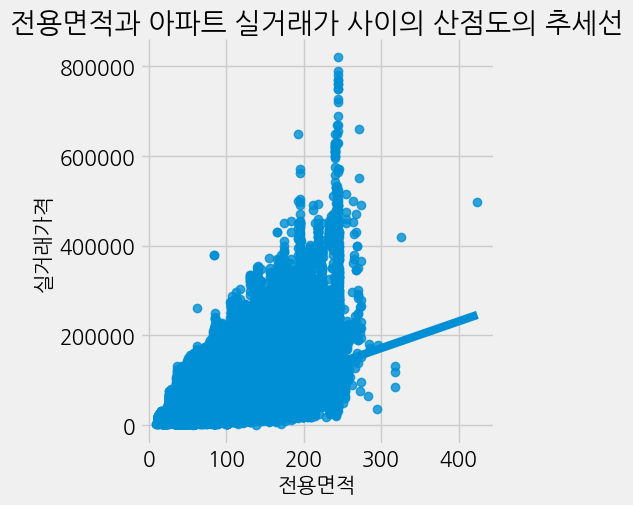

In [119]:
# seaborn을 이용해 전용면적, 실거래가 산점도와 추세선 나타내기

plt.figure(figsize=(12, 8))
sns.lmplot(x='exclusive_use_area', y='transaction_real_price', data=train)
plt.title('전용면적과 아파트 실거래가 사이의 산점도의 추세선', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('전용면적', size=15)
plt.ylabel('실거래가격', size=15)

plt.show()

line plot

In [123]:
# 전용면적당 아파트 거래가 변수를 만들기
train['price_per_area'] = train['transaction_real_price'] / train['exclusive_use_area']


price_per_area_by_year = train.groupby(['year'])['price_per_area'].mean()
price_per_area_by_year

,price_per_area
year,
2008,371.986343
2009,443.344932
2010,387.150633
2011,438.326002
2012,443.270052
2013,449.025207
2014,466.183631
2015,505.157006
2016,559.931274


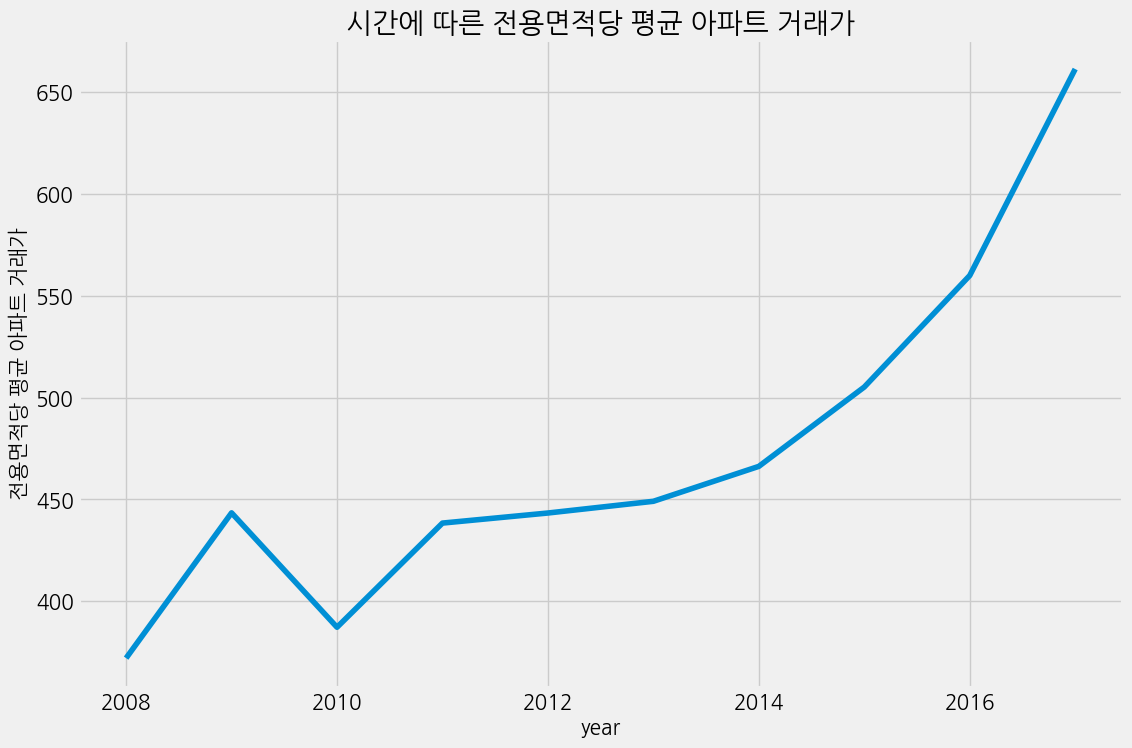

In [127]:
# 일변량 line plot 전용면적당 평균 아파트 거래가 추이 시각화


plt.figure(figsize=(12,8))
plt.plot(price_per_area_by_year.index, price_per_area_by_year)
plt.title('시간에 따른 전용면적당 평균 아파트 거래가', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('year', size=15)
plt.ylabel('전용면적당 평균 아파트 거래가', size=15)
plt.show()

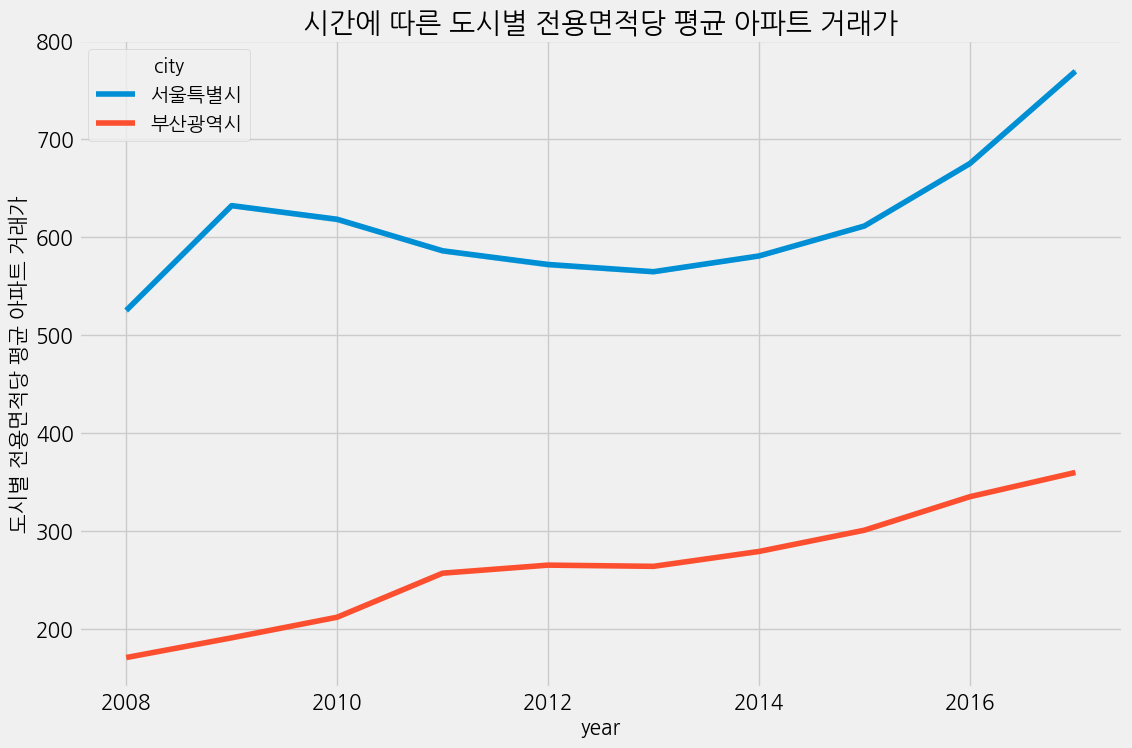

In [128]:
# seaborn 이용한 line plot

plt.figure(figsize=(12,8))
sns.lineplot(x='year', y='price_per_area', hue = 'city', data=train)
plt.title('시간에 따른 도시별 전용면적당 평균 아파트 거래가', size=20)

plt.xticks(size=15)
plt.yticks(size=15)

plt.xlabel('year', size=15)
plt.ylabel('도시별 전용면적당 평균 아파트 거래가', size=15)
plt.show()

#Feature Engineering

평단가

sns.lmplot(data=train, x='exclusive_use_area', y='transaction_real_price', x_bins=200)
-> 너무 느림

<Axes: xlabel='exclusive_use_area', ylabel='transaction_real_price'>

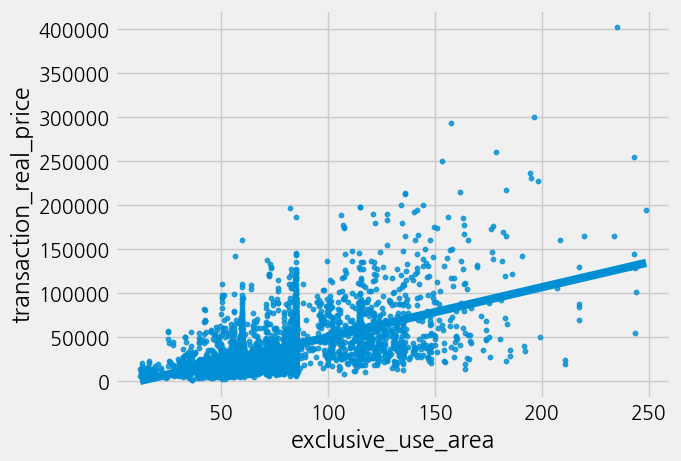

In [133]:
#평단가 lmplot 버리고 빠르게

sns.regplot(
    data=train.sample(5000),
    x='exclusive_use_area',
    y='transaction_real_price',
    scatter_kws={'s': 10},
    ci=None
)


# 평단가 직접 계산 : lmplot 필요없음
# 계산량 줄어듦

In [136]:
train.loc[[5732,566959],:]

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month,price_per_area
5732,5732,4927,서울특별시,신당동,407-17,벨레어카운티,신당동 407-17 벨레어카운티,273.820,2004,200904,21~31,5,95000,2009,4,346.943247
566959,566959,10308,서울특별시,청담동,134-38,청담자이,청담동 134-38 청담자이,49.619,2012,201609,1~10,6,95000,2016,9,1914.589169


In [140]:
# 평당 아파트 실거래가 파생변수

train['price_per_area'] = train['transaction_real_price'] / train['exclusive_use_area']*3.3

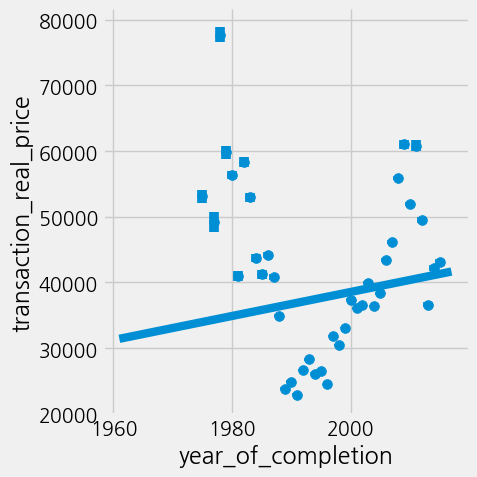

In [139]:
# 아파트 연식 설립연도

sns.regplot(
    data=train.sample(5000),
    x='year_of_completion',
    y='transaction_real_price',
    scatter_kws={'s': 10},
    ci=None
)